In [71]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [72]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from src.data_loader import load_data, basic_cleaning

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

# Business Understanding

AlphaCare Insurance Solutions (ACIS) aims to improve its pricing strategy and identify low-risk customer segments using historical insurance claim data.

The primary business objective is to develop evidence-driven insights that can support:

- Risk-based pricing
- Customer segmentation
- Marketing optimization
- Portfolio profitability improvement

Two key business metrics are used throughout the analysis:

- **Loss Ratio = TotalClaims / TotalPremium**
- **Margin = TotalPremium − TotalClaims**

These metrics help identify profitable and high-risk customer groups.

In [73]:
DATA_PATH = "../data/insurance_data.csv"

df = load_data(DATA_PATH)

df = basic_cleaning(df)

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate,HasClaim,Margin,LossRatio
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10,0,2346.0,0.000000
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13,1,-7549.0,4.234362
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17,0,1697.0,0.000000
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17,1,-9764.0,5.119831
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10,0,2582.0,0.000000


In [74]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 10000
Columns: 24


In [75]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Province',
 'VehicleType',
 'AnnualIncome',
 'RiskScore',
 'AnnualPremium',
 'Deductible',
 'NCD',
 'PastClaims',
 'Claimed',
 'ClaimAmount',
 'TotalPremium',
 'TotalClaims',
 'CoverType',
 'AutoMake',
 'VehicleModel',
 'CustomValueEstimate',
 'ZipCode',
 'TransactionDate',
 'HasClaim',
 'Margin',
 'LossRatio']

In [76]:
df.dtypes.sort_values()

Claimed                   bool
Age                      int64
HasClaim                 int64
ZipCode                  int64
CustomValueEstimate      int64
AnnualIncome             int64
RiskScore                int64
AnnualPremium            int64
Deductible               int64
NCD                      int64
PastClaims               int64
TotalPremium             int64
TotalClaims            float64
LossRatio              float64
Margin                 float64
ClaimAmount            float64
CoverType               object
AutoMake                object
VehicleModel            object
VehicleType             object
Province                object
TransactionDate         object
Gender                  object
CustomerID              object
dtype: object

In [77]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_percent = (
    (df.isnull().sum() / len(df)) * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "MissingValues": missing,
    "MissingPercent": missing_percent
})

missing_df[missing_df["MissingValues"] > 0]

,MissingValues,MissingPercent


# Missing Value Handling Strategy

The dataset contains missing values across several categorical and numerical variables.

Handling strategy:

- Numerical variables:
  - Median imputation for skewed distributions
  - Mean imputation for near-normal distributions

- Categorical variables:
  - Fill with `"Unknown"` category

- Date variables:
  - Converted using `errors='coerce'`

- High-missing columns:
  - Will be evaluated for exclusion during modeling if missingness is excessive.

In [78]:
numerical_cols = df.select_dtypes(include=np.number).columns

df[numerical_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,10000.0,46.68350,16.717963,18.0,32.00,46.0,61.00,75.000000
AnnualIncome,10000.0,79201.97390,33039.939770,17202.0,56105.00,72942.0,95092.00,376916.000000
RiskScore,10000.0,58.14000,14.267486,15.0,48.00,57.0,67.00,95.000000
AnnualPremium,10000.0,2488.12790,735.674491,951.0,2028.00,2307.0,2676.00,5105.000000
Deductible,10000.0,751.70000,500.509401,250.0,500.00,500.0,1000.00,2000.000000
NCD,10000.0,20.93500,14.549122,0.0,10.00,20.0,30.00,50.000000
PastClaims,10000.0,1.06420,1.051945,0.0,0.00,1.0,2.00,5.000000
ClaimAmount,10000.0,1314.18850,3921.864903,0.0,0.00,0.0,0.00,49623.000000
TotalPremium,10000.0,2488.12790,735.674491,951.0,2028.00,2307.0,2676.00,5105.000000
TotalClaims,10000.0,1314.18850,3921.864903,0.0,0.00,0.0,0.00,49623.000000


In [79]:
financial_cols = [
    "TotalPremium",
    "TotalClaims",
    "Margin",
    "LossRatio"
]

df[financial_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
TotalPremium,10000.0,2488.12790,735.674491,951.0,2028.0,2307.0,2676.00,5105.000000
TotalClaims,10000.0,1314.18850,3921.864903,0.0,0.0,0.0,0.00,49623.000000
Margin,10000.0,1173.93940,3742.979999,-44594.0,1812.0,2165.0,2504.25,5079.000000
LossRatio,10000.0,0.44277,1.252813,0.0,0.0,0.0,0.00,15.895383


In [80]:
overall_loss_ratio = (
    df["TotalClaims"].sum() /
    df["TotalPremium"].sum()
)

print(f"Overall Portfolio Loss Ratio: {overall_loss_ratio:.2%}")

Overall Portfolio Loss Ratio: 52.82%


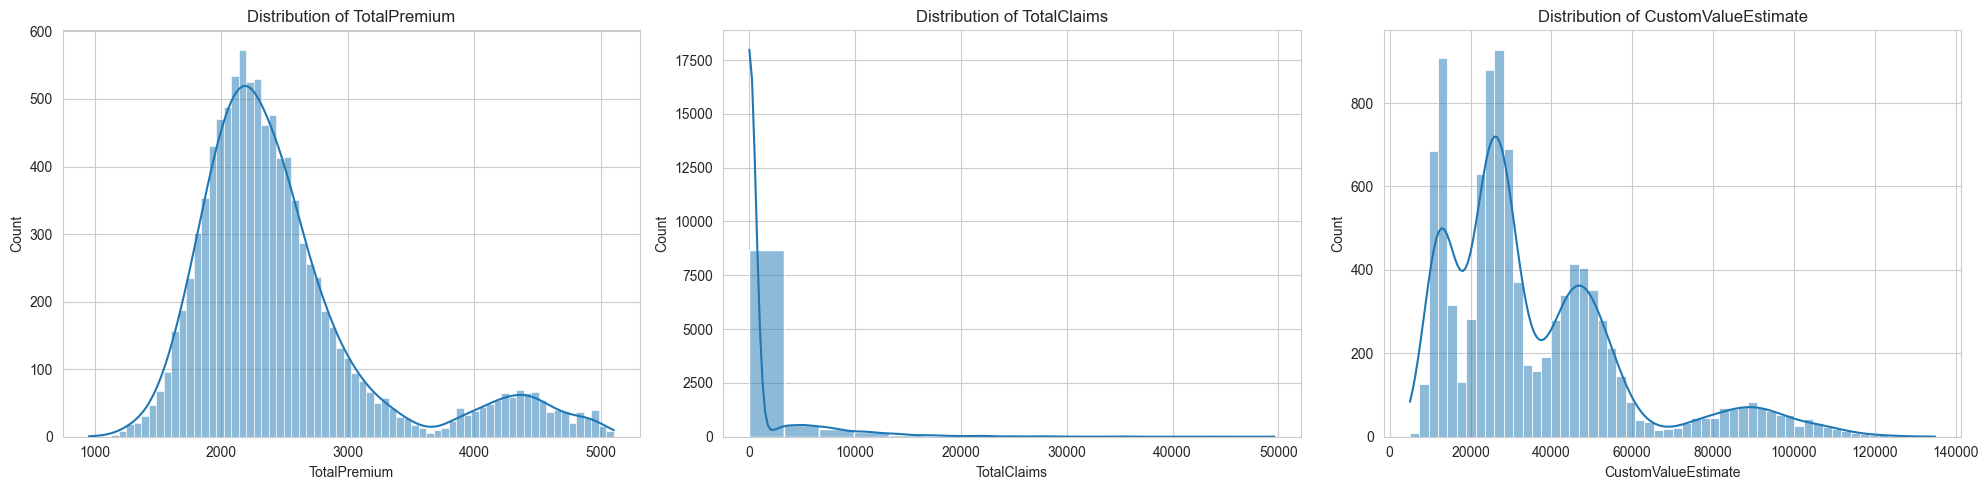

In [81]:
cols = [
    "TotalPremium",
    "TotalClaims",
    "CustomValueEstimate"
]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

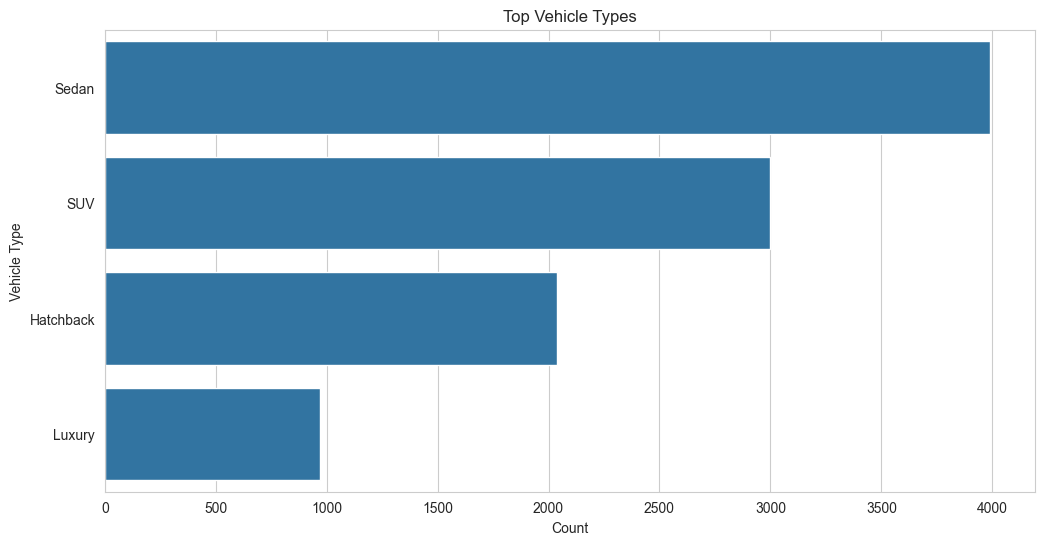

In [82]:
top_vehicle_types = (
    df["VehicleType"]
    .value_counts()
    .head(10)
)

sns.barplot(
    x=top_vehicle_types.values,
    y=top_vehicle_types.index
)

plt.title("Top Vehicle Types")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")

plt.show()

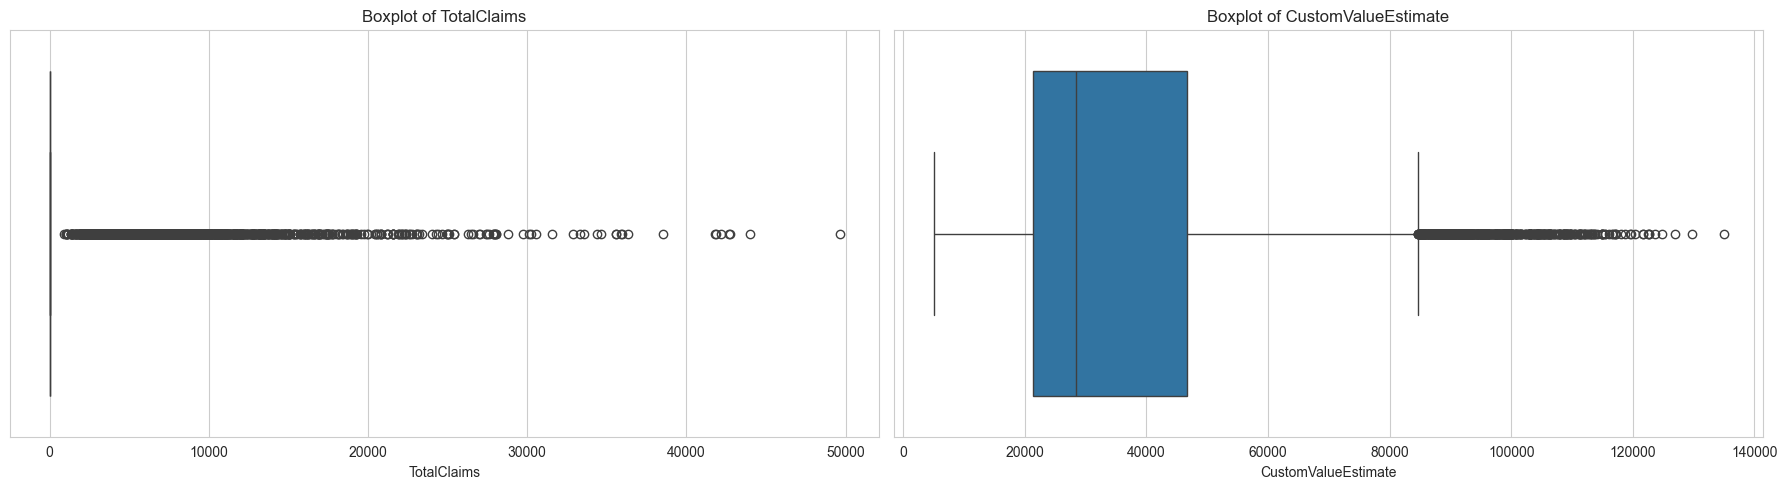

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(x=df["TotalClaims"], ax=axes[0])
axes[0].set_title("Boxplot of TotalClaims")

sns.boxplot(x=df["CustomValueEstimate"], ax=axes[1])
axes[1].set_title("Boxplot of CustomValueEstimate")

plt.tight_layout()
plt.show()

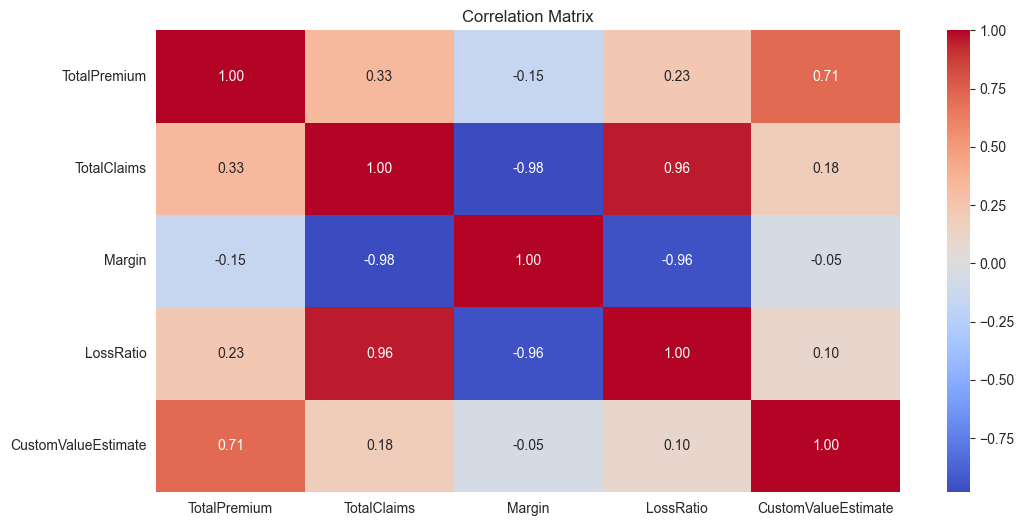

In [84]:
corr_cols = [
    "TotalPremium",
    "TotalClaims",
    "Margin",
    "LossRatio",
    "CustomValueEstimate"
]

corr = df[corr_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

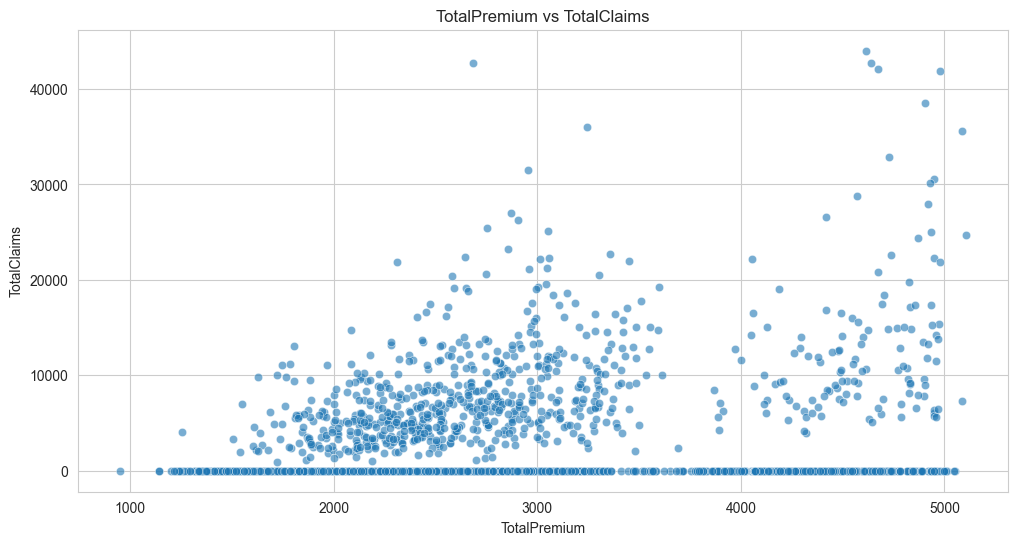

In [85]:
sample_df = df.sample(5000, random_state=42)

sns.scatterplot(
    data=sample_df,
    x="TotalPremium",
    y="TotalClaims",
    alpha=0.6
)

plt.title("TotalPremium vs TotalClaims")
plt.show()

In [86]:
province_loss = (
    df.groupby("Province")
    .agg({
        "TotalPremium": "sum",
        "TotalClaims": "sum"
    })
)

province_loss["LossRatio"] = (
    province_loss["TotalClaims"] /
    province_loss["TotalPremium"]
)

province_loss = province_loss.sort_values(
    "LossRatio",
    ascending=False
)

province_loss

,TotalPremium,TotalClaims,LossRatio
Province,,,
Somali,2984984,1826593.0,0.611927
Oromia,6069663,3261061.0,0.537272
Tigray,1990692,1047136.0,0.526016
Addis Ababa,8907374,4653210.0,0.522400
Amhara,4928566,2353885.0,0.477600


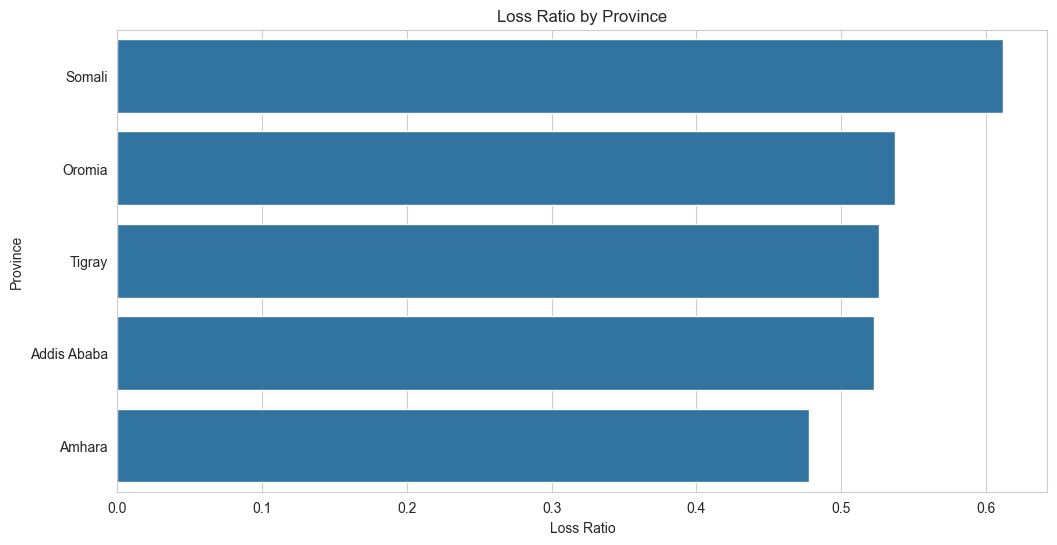

In [87]:
sns.barplot(
    data=province_loss.reset_index(),
    x="LossRatio",
    y="Province"
)

plt.title("Loss Ratio by Province")
plt.xlabel("Loss Ratio")
plt.ylabel("Province")

plt.show()

In [88]:
vehicle_risk = (
    df.groupby("VehicleType")
    .agg({
        "TotalClaims": "mean",
        "LossRatio": "mean"
    })
    .sort_values("TotalClaims", ascending=False)
    .head(10)
)

vehicle_risk

,TotalClaims,LossRatio
VehicleType,,
Luxury,3672.023663,0.803672
SUV,1363.555000,0.499749
Hatchback,935.282417,0.370846
Sedan,896.236974,0.348758


In [89]:
gender_risk = (
    df.groupby("Gender")
    .agg({
        "LossRatio": "mean",
        "TotalClaims": "mean"
    })
)

gender_risk

,LossRatio,TotalClaims
Gender,,
Female,0.447351,1316.276761
Male,0.437929,1311.981695


In [90]:
df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], errors="coerce")

monthly_trends = (
    df.groupby(df["TransactionDate"].dt.to_period("M"))
    .agg({
        "TotalClaims": "sum",
        "HasClaim": "mean"
    })
)

monthly_trends.index = monthly_trends.index.astype(str)

monthly_trends.head()

,TotalClaims,HasClaim
TransactionDate,,
2024-01,764324.0,0.139785
2024-02,661946.0,0.143126
2024-03,725682.0,0.150558
2024-04,751881.0,0.160940
2024-05,941073.0,0.172174


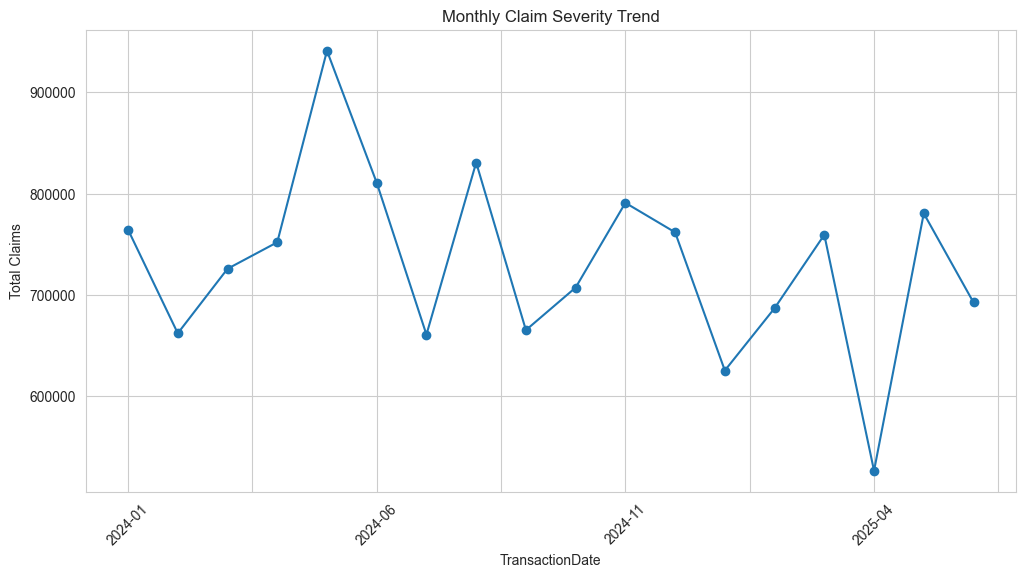

In [91]:
monthly_trends["TotalClaims"].plot(marker="o")

plt.title("Monthly Claim Severity Trend")
plt.ylabel("Total Claims")

plt.xticks(rotation=45)

plt.show()

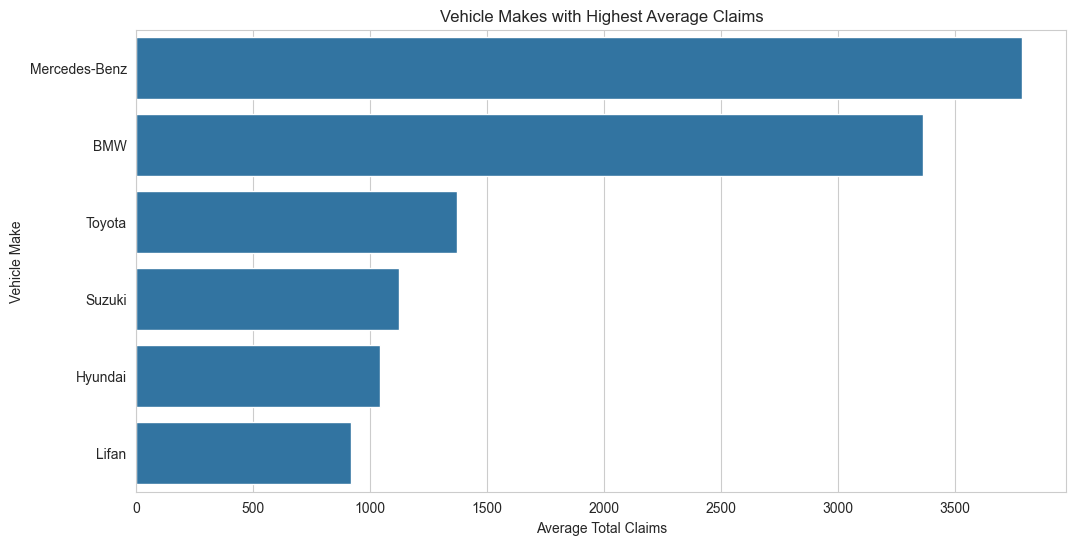

In [92]:
top_makes = (
    df.groupby("AutoMake")["TotalClaims"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

sns.barplot(
    x=top_makes.values,
    y=top_makes.index
)

plt.title("Vehicle Makes with Highest Average Claims")
plt.xlabel("Average Total Claims")
plt.ylabel("Vehicle Make")

plt.show()

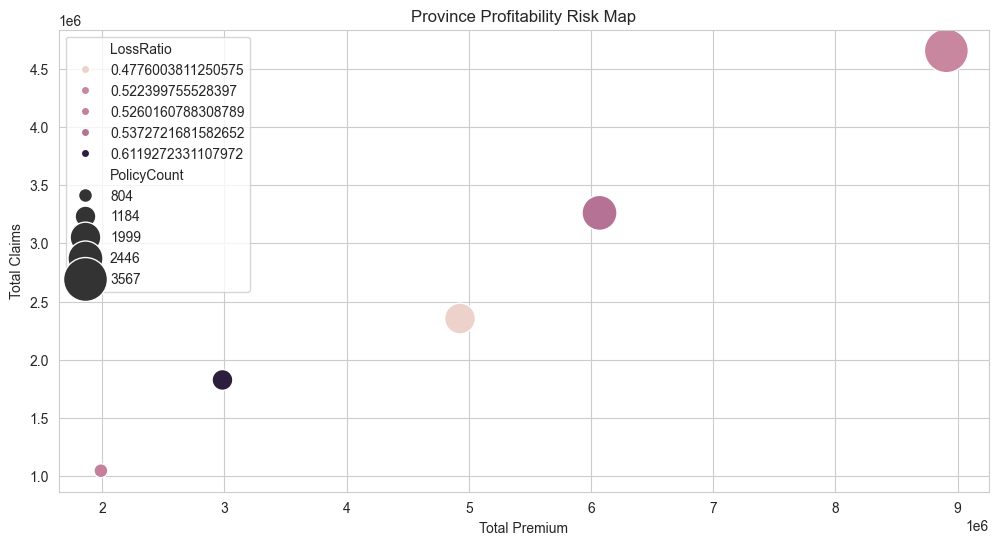

In [93]:
province_summary = (
    df.groupby("Province")
    .agg(
        TotalPremium=("TotalPremium", "sum"),
        TotalClaims=("TotalClaims", "sum"),
        PolicyCount=("TotalPremium", "count")
    )
    .reset_index()
)

province_summary["LossRatio"] = (
    province_summary["TotalClaims"] /
    province_summary["TotalPremium"].replace(0, np.nan)
)

sns.scatterplot(
    data=province_summary,
    x="TotalPremium",
    y="TotalClaims",
    size="PolicyCount",
    hue="LossRatio",
    sizes=(100, 1000)
)

plt.title("Province Profitability Risk Map")
plt.xlabel("Total Premium")
plt.ylabel("Total Claims")

plt.show()

# Key Insights and Recommendations

## Key Findings

- Several provinces exhibit significantly higher loss ratios, indicating elevated insurance risk exposure.
- Certain vehicle types and makes consistently produce higher average claim amounts.
- The dataset contains extreme outliers in TotalClaims and CustomValueEstimate that may influence predictive modeling.
- Temporal analysis suggests fluctuations in claim severity across months, potentially linked to seasonality or operational factors.
- Premium and claim relationships vary considerably across geographic regions.

## Business Recommendations

- Implement province-specific pricing adjustments for high-loss regions.
- Introduce targeted marketing campaigns toward low-risk customer segments.
- Review underwriting rules for high-risk vehicle categories.
- Incorporate vehicle age and regional risk into premium optimization models.
- Apply robust outlier handling before statistical modeling to improve predictive stability.

In [94]:
from src.feature_engineering import clean_dataset

clean_df = clean_dataset(df)

clean_df.to_csv("../data/insurance_data_cleaned.csv", index=False)